# Name : Bansi Ajagia
# **Subject** : Machine Learning
# **Project** : Cardiovascular Disease Prediction System

---

# Task 6 — Visualization of Metrics & Graphs

In [3]:
# Name : Bansi Ajagia
# Subject : Machine Learning
# Project : Cardiovascular Disease Prediction System

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/cardio.csv', sep=';')
df['age_years'] = (df['age'] / 365).round(0).astype(int)
df = df[df['ap_hi'].between(60,250)]
df = df[df['ap_lo'].between(40,200)]
df = df[df['height'].between(100,250)]
df = df[df['weight'].between(30,250)]
print('Data loaded.')

Data loaded.


## 1️⃣ Correlation Heatmap

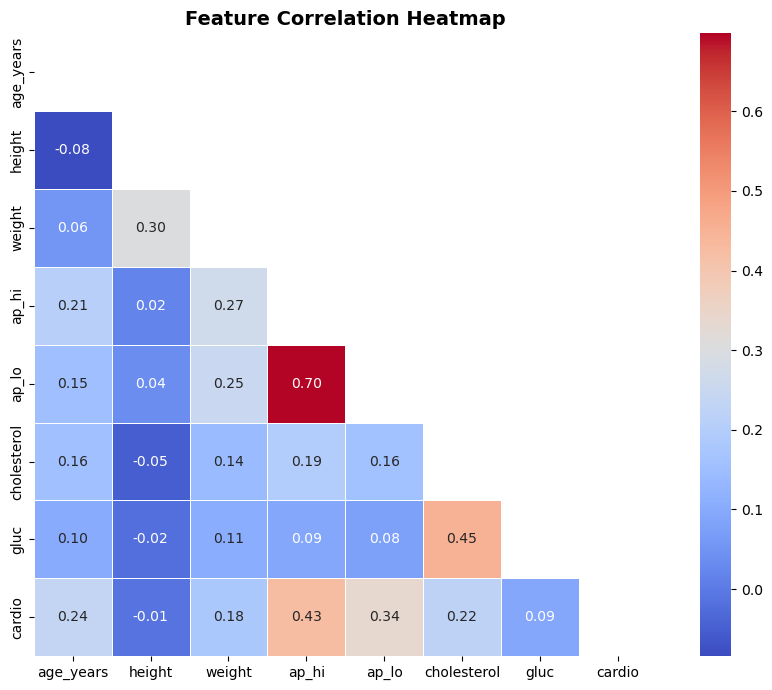

In [5]:
num_cols = ['age_years','height','weight','ap_hi','ap_lo','cholesterol','gluc','cardio']
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            ax=ax, linewidths=0.5, square=True)
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/heatmap.png', dpi=120)
plt.show()

## 2️⃣ Age & BP Histograms

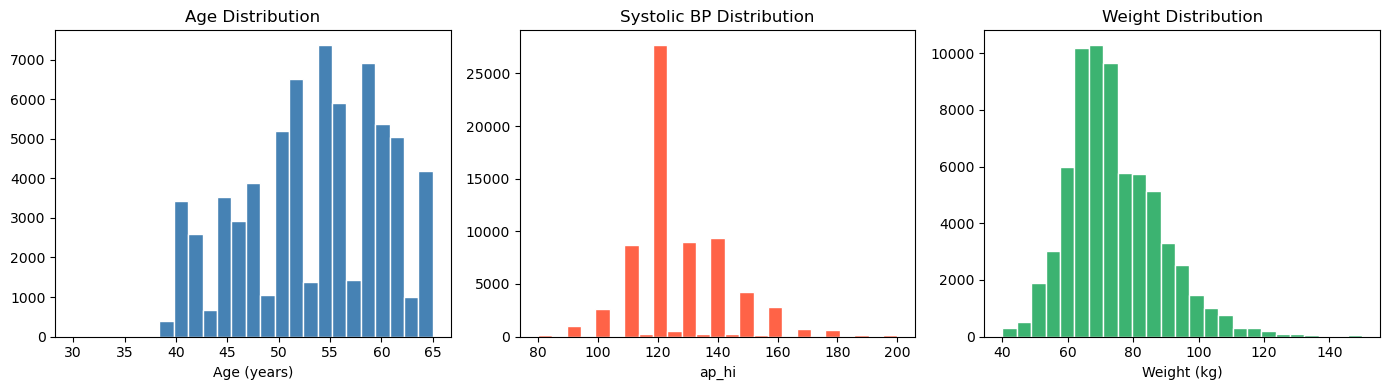

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(df['age_years'], bins=25, color='steelblue', edgecolor='white')
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age (years)')

axes[1].hist(df['ap_hi'].clip(80,200), bins=25, color='tomato', edgecolor='white')
axes[1].set_title('Systolic BP Distribution')
axes[1].set_xlabel('ap_hi')

axes[2].hist(df['weight'].clip(40,150), bins=25, color='mediumseagreen', edgecolor='white')
axes[2].set_title('Weight Distribution')
axes[2].set_xlabel('Weight (kg)')

plt.tight_layout()
plt.savefig('../outputs/histograms.png', dpi=120)
plt.show()

## 3️⃣ Countplots by Disease Status

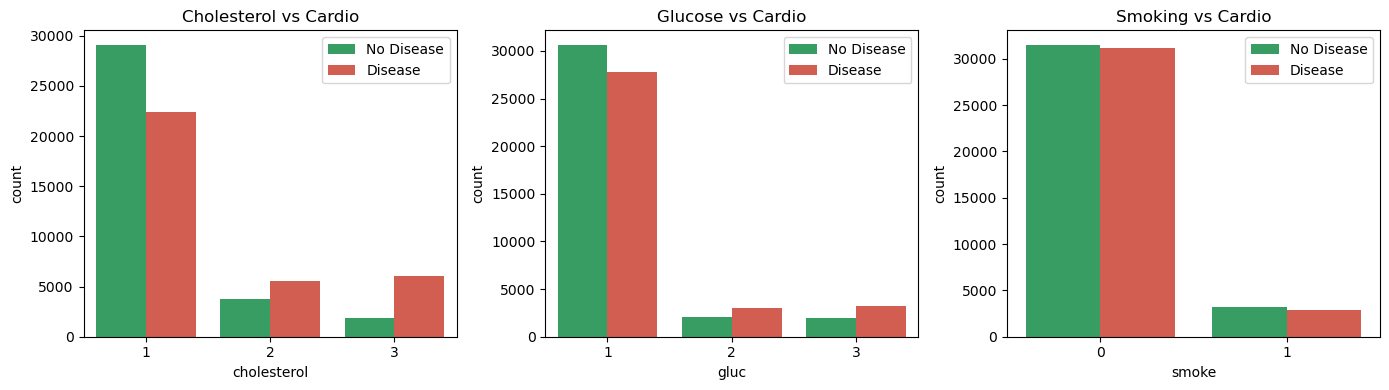

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col, title in zip(axes, ['cholesterol','gluc','smoke'],
                          ['Cholesterol','Glucose','Smoking']):
    sns.countplot(data=df, x=col, hue='cardio', palette=['#27ae60','#e74c3c'], ax=ax)
    ax.set_title(f'{title} vs Cardio')
    ax.legend(['No Disease','Disease'])

plt.tight_layout()
plt.savefig('../outputs/countplots.png', dpi=120)
plt.show()

## 4️⃣ Confusion Matrix Visualization (from saved file)

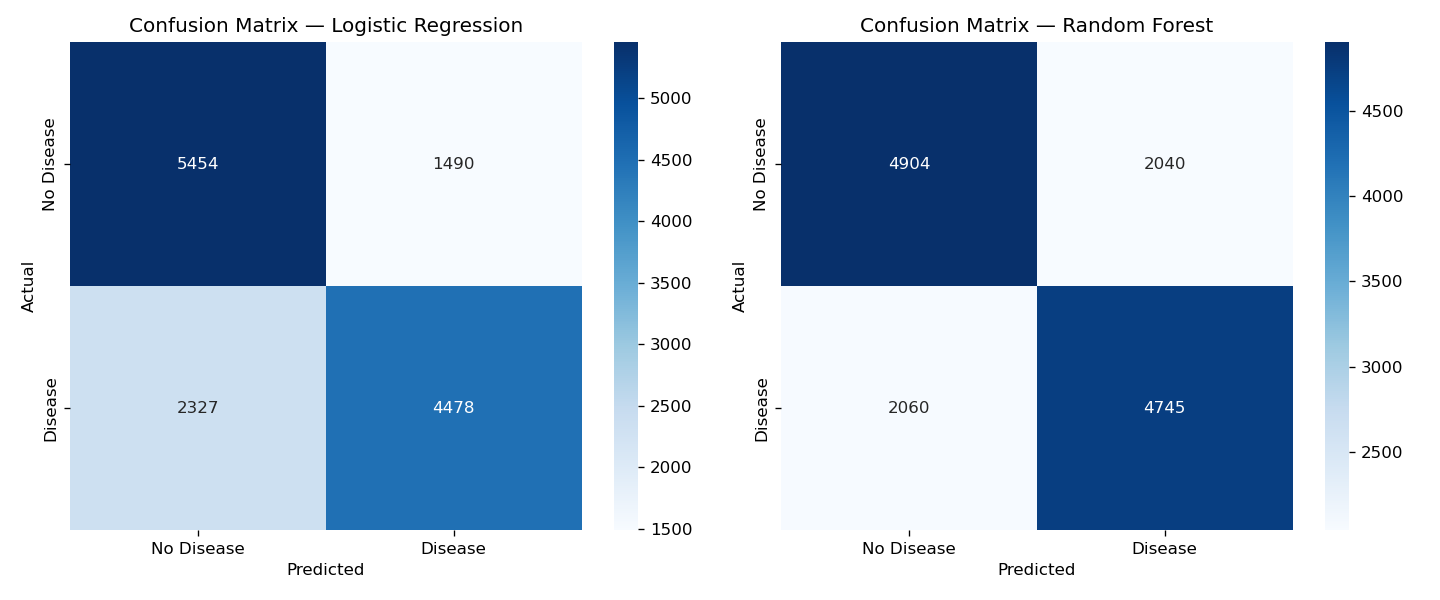

In [11]:
import os
if os.path.exists('../outputs/confusion_matrix.png'):
    from IPython.display import Image
    display(Image('../outputs/confusion_matrix.png'))
else:
    print('Run task4 first to generate confusion_matrix.png')